# Estrazione di picchi su tutto il dataset

In [173]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json

In [174]:
%matplotlib widget
plt.close('all')

In [175]:
base_dir = "dati_processati"
spettri_dir = "spettri_5_periodi/"

dir = os.path.join(base_dir, spettri_dir)

available_files = [f for f in os.listdir(dir) if f.endswith('.npz')]
note_inds = [int(f.split('_')[1].split(".")[0]) for f in available_files]

print("Available files:")
for f, note_ind in zip(available_files, note_inds):
    print(f"File: {f}, Note Index: {note_ind}")

Available files:
File: note_5.wav_spectrum.npz, Note Index: 5
File: note_7.wav_spectrum.npz, Note Index: 7
File: note_158.wav_spectrum.npz, Note Index: 158
File: note_263.wav_spectrum.npz, Note Index: 263
File: note_152.wav_spectrum.npz, Note Index: 152
File: note_48.wav_spectrum.npz, Note Index: 48
File: note_259.wav_spectrum.npz, Note Index: 259
File: note_97.wav_spectrum.npz, Note Index: 97
File: note_79.wav_spectrum.npz, Note Index: 79
File: note_95.wav_spectrum.npz, Note Index: 95
File: note_91.wav_spectrum.npz, Note Index: 91
File: note_175.wav_spectrum.npz, Note Index: 175
File: note_112.wav_spectrum.npz, Note Index: 112
File: note_250.wav_spectrum.npz, Note Index: 250
File: note_149.wav_spectrum.npz, Note Index: 149
File: note_77.wav_spectrum.npz, Note Index: 77
File: note_118.wav_spectrum.npz, Note Index: 118
File: note_220.wav_spectrum.npz, Note Index: 220
File: note_163.wav_spectrum.npz, Note Index: 163
File: note_248.wav_spectrum.npz, Note Index: 248
File: note_194.wav_spec

In [176]:
# sort files by note index
sorted_files = [f for _, f in sorted(zip(note_inds, available_files))]
sorted_note_inds = sorted(note_inds)

In [177]:
# carica uno spettro alla volta, estrai i picchi e salvali in un dict

out_dict = {}

for filename, note_ind in zip(sorted_files, sorted_note_inds):
    data = np.load(os.path.join(dir, filename))
    freqs = data['freqs']
    avg_spectrum = data['avg_spectrum']
    mags = np.abs(avg_spectrum)

    log10_mags = np.log10(mags + 1e-10)  # Aggiungi un piccolo valore per evitare log(0)
    
    # Estrai i picchi
    peaks, _ = sp.signal.find_peaks(log10_mags, prominence=2)
    peak_freqs = freqs[peaks]
    peak_mags = mags[peaks]

    out_dict[f"Nota_{note_ind}"] = {
        "peaks" : {
            'frequencies': list(peak_freqs),
            'magnitudes': list(peak_mags)
        }
    }

    print(f"Processed {filename}: Found {len(peaks)} peaks")
    

Processed note_1.wav_spectrum.npz: Found 10 peaks
Processed note_2.wav_spectrum.npz: Found 9 peaks
Processed note_3.wav_spectrum.npz: Found 12 peaks
Processed note_4.wav_spectrum.npz: Found 43 peaks
Processed note_5.wav_spectrum.npz: Found 35 peaks
Processed note_6.wav_spectrum.npz: Found 8 peaks
Processed note_7.wav_spectrum.npz: Found 13 peaks
Processed note_8.wav_spectrum.npz: Found 15 peaks
Processed note_9.wav_spectrum.npz: Found 10 peaks
Processed note_10.wav_spectrum.npz: Found 50 peaks
Processed note_11.wav_spectrum.npz: Found 11 peaks
Processed note_12.wav_spectrum.npz: Found 6 peaks
Processed note_13.wav_spectrum.npz: Found 12 peaks
Processed note_14.wav_spectrum.npz: Found 8 peaks
Processed note_15.wav_spectrum.npz: Found 6 peaks
Processed note_16.wav_spectrum.npz: Found 5 peaks
Processed note_17.wav_spectrum.npz: Found 10 peaks
Processed note_18.wav_spectrum.npz: Found 4 peaks
Processed note_19.wav_spectrum.npz: Found 9 peaks
Processed note_20.wav_spectrum.npz: Found 3 peak

In [178]:
output_file = f"{base_dir}/{spettri_dir.replace('/', '_')}peaks.json"

with open(output_file, 'w') as f:
    json.dump(out_dict, f, indent=4)

Dropdown(description='Nota:', options=('note_1.wav_spectrum.npz', 'note_2.wav_spectrum.npz', 'note_3.wav_spect…

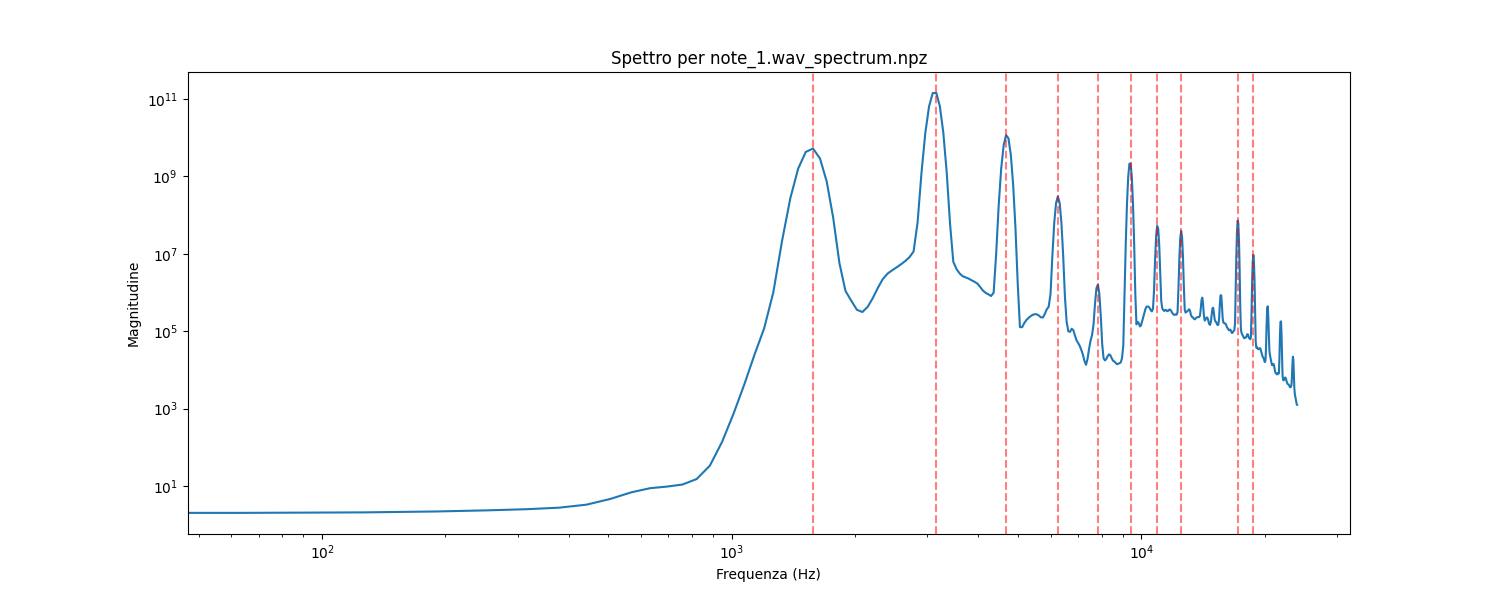

In [179]:
note_selector = widgets.Dropdown(
    options=sorted_files,
    description='Nota:',
)

fig, ax = plt.subplots()
fig.set_size_inches(15, 6)

def update_plot(change):

    filename = change["new"]
    
    data = np.load(os.path.join(base_dir, spettri_dir, filename))
    freqs = data['freqs']
    avg_spectrum = data['avg_spectrum']
    mags = np.abs(avg_spectrum)

    peaks = out_dict[f"Nota_{int(filename.split('_')[1].split('.')[0])}"]["peaks"]
    peaks = np.array(peaks['frequencies'])

    ax.clear()

    ax.plot(freqs, mags)
    
    for peak in peaks:
        ax.axvline(peak, color='red', linestyle='--', alpha=0.5)

    ax.set_title(f"Spettro per {filename}")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Magnitudine")

    ax.set_xscale('log')
    ax.set_yscale('log')



note_selector.observe(update_plot, names='value')
display(note_selector)
update_plot({'new': note_selector.value})